In [1]:
import cv2 as cv
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

### Undistord frames

Camera parameters

In [6]:
K = np.array([[533.340727445877, 0.0, 254.64689387916482],
              [0.0, 533.2556495307942, 256.4835490935692],
              [0.0, 0.0, 1.0]])

xi = np.array([[1.73241756065]])

D = np.array([-0.05972430882700243, 0.17468739202093328, 0.000737218969875311, 0.000574074894976456])

W = H = 512

In [17]:
images_dir = Path("/home/zhukowych/Projects/ucu/MMML/SULLLAM/data/frames")
undistorted_dir = Path("/home/zhukowych/Projects/ucu/MMML/SULLLAM/data/frames_undistorted")

images_paths = list(images_dir.glob("*.png"))

for image_path in images_paths:

    distorted_image = cv.imread(image_path)
    newK = K.copy()

    undistorted_image = cv.omnidir.undistortImage(
        distorted_image,
        K, 
        D, 
        xi, 
        cv.omnidir.RECTIFY_PERSPECTIVE,
        Knew=newK
    )

    cv.imwrite(undistorted_dir / image_path.name, undistorted_image)

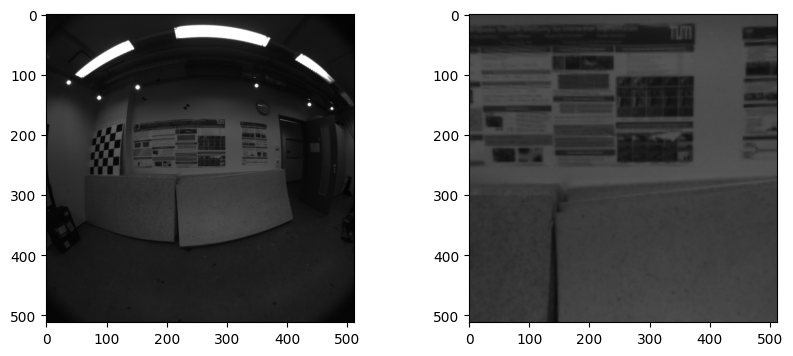

In [16]:
distorted_image = cv.imread(images_paths[0])

newK = K.copy()

undistorted_image = cv.omnidir.undistortImage(
    distorted_image,
    K, 
    D, 
    xi, 
    cv.omnidir.RECTIFY_PERSPECTIVE,
    Knew=newK
)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(distorted_image)
ax[1].imshow(undistorted_image)

plt.show()

In [18]:
newK

array([[533.34072745,   0.        , 254.64689388],
       [  0.        , 533.25564953, 256.48354909],
       [  0.        ,   0.        ,   1.        ]])